# Qwen Judge — Local Setup & Run (Windows WSL)

This notebook runs the LLM-as-a-judge pipeline using **Qwen2.5-7B-Instruct** locally via Ollama.  
It scores all 4,800 model explanations on two criteria (accuracy + completeness = 9,600 total calls)  
and saves results to `outputs/ratings_judge.jsonl`.

**Platform:** Windows WSL (Ubuntu)  
**Estimated time:** 3–6 hours (faster with NVIDIA GPU, slower CPU-only)  
**Cost:** Free — everything runs on your machine, no API keys needed.

---
## Before opening this notebook
Make sure you opened Jupyter from inside your conda environment:
```bash
conda activate applesVsOranges
cd /mnt/d/ApplesVSOranges
jupyter notebook run_judge.ipynb
```

---
## Sections
1. Install Ollama & pull the model *(one-time setup)*
2. Verify setup
3. Quick smoke test (4 calls)
4. **Full run** (9,600 calls)
5. Inspect results
6. Compare our judge vs. paper's Qwen-72B baseline

---
## Section 1 — One-Time Setup
Run these cells **once** on first use. Skip on subsequent runs.

In [5]:
# 1a. Install Ollama (WSL/Linux)
import shutil
if shutil.which("ollama"):
    print("Ollama already installed:", shutil.which("ollama"))
else:
    print("Installing Ollama for WSL/Linux ...")
    !curl -fsSL https://ollama.com/install.sh | sh
    print("Done")

Ollama already installed: /usr/local/bin/ollama


In [6]:
# 1b. Start the Ollama daemon
# WSL note: the daemon must be started each time you open a new WSL session.
# 'address already in use' just means it is already running — that is fine.

import subprocess, time, requests

def ollama_is_running():
    try:
        requests.get("http://localhost:11434/api/tags", timeout=3)
        return True
    except Exception:
        return False

if ollama_is_running():
    print("Ollama is already running on port 11434")
else:
    print("Starting Ollama daemon ...")
    subprocess.Popen(
        ["ollama", "serve"],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    for i in range(15):
        time.sleep(1)
        if ollama_is_running():
            print(f"Ollama daemon started (took {i+1}s)")
            break
    else:
        print("Daemon did not respond after 15s.")
        print("Try: open a separate WSL terminal and run 'ollama serve', then re-run this cell.")

Ollama is already running on port 11434


In [7]:
# 1c. Pull the Qwen model (~4.4 GB, one-time download, 5-20 min)
MODEL = "qwen2.5:7b-instruct-q4_K_M"
print(f"Pulling {MODEL} ...")
!ollama pull {MODEL}
print("Model ready")

Pulling qwen2.5:7b-instruct-q4_K_M ...
/bin/bash: /home/khois345/miniconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
]11;?\pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest 
pulling 2bada8a74506:  18% ▕███               ▏ 825 MB/4.7 GB                  pulling manifest 
pulling 2bada8a74506:  18% ▕███               ▏ 825 MB/4.7 GB                  pulling manifest 
pulling 2bada8a74506:  18% ▕███               ▏ 827 MB/4.7 GB                  pulling manifest 
pulling 2bada8a74506:  18% ▕███               ▏ 830 MB/4.7 GB                  pulling manifest 
pulling 2bada8a74506:  18% ▕███               ▏ 835 MB/4.7 GB                  pulling manifest 
pulling 2bada8a74506:  18% ▕███               ▏ 841 MB/4.7 GB                  pulling manifest 
pulling 2bada8a74506:  18% ▕███               ▏ 847 MB/4.7 GB                  pulling manifest 
pulling 2bada8a74506:  18% ▕███               ▏ 

In [8]:
# 1d. Check GPU availability (informational only)
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available: ", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:            ", torch.cuda.get_device_name(0))
    print("\nOllama will use your GPU. Expect ~3 hrs for the full run.")
else:
    print("\nNo CUDA GPU detected. Ollama will run on CPU.")
    print("Expect ~5-8 hrs. Fine to leave running overnight.")

PyTorch version: 2.11.0+cu130
CUDA available:  True
GPU:             NVIDIA GeForce RTX 3090

Ollama will use your GPU. Expect ~3 hrs for the full run.


---
## Section 2 — Verify Setup

In [9]:
# 2a. Check Ollama is reachable and the model is listed
import requests

OLLAMA_URL = "http://localhost:11434"
MODEL = "qwen2.5:7b-instruct-q4_K_M"

try:
    resp = requests.get(f"{OLLAMA_URL}/api/tags", timeout=10)
    resp.raise_for_status()
    models_available = [m["name"] for m in resp.json().get("models", [])]
    print("Models in Ollama:")
    for m in models_available:
        marker = ">>> " if MODEL in m else "    "
        print(f"{marker}{m}")
    if not any(MODEL in m for m in models_available):
        print(f"\nWARNING: '{MODEL}' not found. Run Section 1c first.")
    else:
        print("\nModel found. Ready to judge.")
except requests.exceptions.ConnectionError:
    print("ERROR: Cannot reach Ollama on port 11434.")
    print("Run Section 1b again, or run 'ollama serve' in a separate WSL terminal.")

Models in Ollama:
>>> qwen2.5:7b-instruct-q4_K_M

Model found. Ready to judge.


In [10]:
# 2b. Check data files
from pathlib import Path

required = {
    "data/jokes.jsonl":                "600 jokes",
    "data/explanations.jsonl":         "4,800 model explanations",
    "prompts/judge_template.txt":      "judge prompt template",
    "prompts/rubric_accuracy.txt":     "accuracy rubric",
    "prompts/rubric_completeness.txt": "completeness rubric",
}

all_ok = True
for path, desc in required.items():
    p = Path(path)
    if p.exists():
        lines = sum(1 for _ in p.open(encoding="utf-8")) if p.suffix == ".jsonl" else ""
        detail = f"({lines} lines)" if lines else ""
        print(f"  OK  {path} {detail}")
    else:
        print(f"  MISSING  {path}  ({desc})")
        all_ok = False

print()
if all_ok:
    print("All files present. Safe to continue.")
else:
    print("Fix missing files before continuing.")
    print("Make sure you opened Jupyter from inside /mnt/d/ApplesVSOranges")

  OK  data/jokes.jsonl (600 lines)
  OK  data/explanations.jsonl (4800 lines)
  OK  prompts/judge_template.txt 
  OK  prompts/rubric_accuracy.txt 
  OK  prompts/rubric_completeness.txt 

All files present. Safe to continue.


---
## Section 3 — Smoke Test (4 calls)

Run 4 judge calls to confirm the pipeline works before starting the 9,600-call full run.  
Should complete in under 2 minutes.

In [11]:
# Load all static data + define helpers
# Run this cell before the smoke test AND before the full run.

import json, time, re, logging
from pathlib import Path
import requests
from tqdm.notebook import tqdm

logging.basicConfig(level=logging.WARNING)

OLLAMA_CHAT_URL = "http://localhost:11434/v1/chat/completions"
MODEL           = "qwen2.5:7b-instruct-q4_K_M"
TEMPERATURE     = 0.1   # paper value — Appendix A.6
MAX_TOKENS      = 16    # response is a single digit; 16 gives headroom
RETRIES         = 3
RETRY_SLEEP     = 3


def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


def load_text(path):
    return Path(path).read_text(encoding="utf-8").strip()


def parse_score(text):
    """Extract first integer 0-5 from judge response."""
    m = re.search(r"[0-5]", text)
    return int(m.group()) if m else None


def call_ollama(messages):
    """Call Ollama with retries. Returns raw text response."""
    for attempt in range(RETRIES):
        try:
            resp = requests.post(
                OLLAMA_CHAT_URL,
                json={
                    "model":       MODEL,
                    "messages":    messages,
                    "temperature": TEMPERATURE,
                    "max_tokens":  MAX_TOKENS,
                },
                timeout=180,
            )
            resp.raise_for_status()
            return resp.json()["choices"][0]["message"]["content"]
        except Exception as e:
            if attempt == RETRIES - 1:
                raise
            time.sleep(RETRY_SLEEP * (attempt + 1))


def build_prompt(template, criterion, rubric, joke, reference, explanation):
    return template.format(
        criteria=criterion,
        scoring_criteria=rubric.rstrip("\n"),
        joke=joke,
        reference_explanation=reference,
        model_explanation=explanation,
    )


# Load static data (reused by smoke test and full run)
jokes        = {j["id"]: j for j in load_jsonl("data/jokes.jsonl")}
explanations = load_jsonl("data/explanations.jsonl")
template     = load_text("prompts/judge_template.txt")
rubrics = {
    "accuracy":     load_text("prompts/rubric_accuracy.txt"),
    "completeness": load_text("prompts/rubric_completeness.txt"),
}

print(f"Loaded {len(jokes)} jokes and {len(explanations)} explanations")

Loaded 600 jokes and 4800 explanations


In [12]:
# Smoke test: 2 explanations x 2 criteria = 4 calls
print("Running smoke test (4 calls) ...\n")

smoke_results = []
for expl in explanations[:2]:
    joke = jokes[expl["joke_id"]]
    for criterion in ["accuracy", "completeness"]:
        prompt = build_prompt(
            template, criterion, rubrics[criterion],
            joke["joke"], joke["reference_explanation"], expl["explanation"]
        )
        raw   = call_ollama([{"role": "user", "content": prompt}])
        score = parse_score(raw)
        smoke_results.append({"joke_id": expl["joke_id"], "model": expl["model"],
                               "criterion": criterion, "score": score, "raw": raw})
        status = f"score={score}" if score is not None else "PARSE FAILED"
        print(f"  {expl['joke_id']:<22} {expl['model'][:14]:<14} {criterion:<12} raw={raw!r:<8} {status}")

ok   = sum(1 for r in smoke_results if r["score"] is not None)
fail = len(smoke_results) - ok
print()
if fail == 0:
    print("All 4 calls parsed successfully. Safe to run Section 4.")
else:
    print(f"{fail}/4 calls failed. Check Ollama is running and the model is loaded.")

Running smoke test (4 calls) ...

  topical_000            gpt-4o         accuracy     raw='4'      score=4
  topical_000            gpt-4o         completeness raw='4'      score=4
  topical_000            gpt-4o-mini    accuracy     raw='4'      score=4
  topical_000            gpt-4o-mini    completeness raw='4'      score=4

All 4 calls parsed successfully. Safe to run Section 4.


---
## Section 4 — Full Run (9,600 calls)

**Expected time:** 3–8 hours depending on your hardware.

### WSL tips before starting:
- **Do not close your WSL window** while the run is in progress — it will kill the kernel
- **Safe to interrupt** with `Kernel > Interrupt` at any time — progress saves after every call
- **To resume** after an interruption: re-run the data-loading cell in Section 3, then re-run the two cells below
- **Prevent sleep:** open Windows Power Settings and set Sleep to Never while the run is going

In [13]:
# Build work list and show resume status
import datetime

OUTPUT_PATH = Path("outputs/ratings_judge.jsonl")
ERROR_LOG   = Path("outputs/judge_errors.log")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

CRITERIA = ["accuracy", "completeness"]


def load_done(path):
    done = set()
    if path.exists():
        for row in load_jsonl(path):
            done.add((row["joke_id"], row["model"], row["criterion"]))
    return done


all_work = [
    (e["joke_id"], e["model"], e["explanation"], crit)
    for e in explanations
    for crit in CRITERIA
]

done = load_done(OUTPUT_PATH)
todo = [(jid, mdl, expl, crit) for jid, mdl, expl, crit in all_work
        if (jid, mdl, crit) not in done]

pct = len(done) / len(all_work) * 100 if all_work else 0
print(f"Total calls:   {len(all_work):,}")
print(f"Already done:  {len(done):,}  ({pct:.1f}%)")
print(f"Remaining:     {len(todo):,}")
if len(todo) == 0:
    print("\nAll 9,600 calls complete. Jump to Section 5.")

Total calls:   9,600
Already done:  0  (0.0%)
Remaining:     9,600


In [14]:
# Run the judge
# Re-run this cell to resume after any interruption.

n_ok = n_backend_err = n_parse_err = 0
session_start = datetime.datetime.now()

with OUTPUT_PATH.open("a", encoding="utf-8") as out_f, \
     ERROR_LOG.open("a", encoding="utf-8") as err_f:

    for joke_id, model, explanation, criterion in tqdm(todo, desc="Judging"):

        joke = jokes.get(joke_id)
        if joke is None:
            err_f.write(f"unknown joke_id={joke_id!r}\n")
            n_backend_err += 1
            continue

        prompt = build_prompt(
            template, criterion, rubrics[criterion],
            joke["joke"], joke["reference_explanation"], explanation
        )

        try:
            raw   = call_ollama([{"role": "user", "content": prompt}])
            score = parse_score(raw)
        except Exception as e:
            err_f.write(f"backend error ({joke_id}, {model}, {criterion}): {e!r}\n")
            n_backend_err += 1
            continue

        if score is None:
            err_f.write(f"unparseable ({joke_id}, {model}, {criterion}): {raw!r}\n")
            n_parse_err += 1
            continue

        row = {"joke_id": joke_id, "model": model,
               "criterion": criterion, "score": score,
               "annotator": "qwen2.5-7b-instruct"}
        out_f.write(json.dumps(row) + "\n")
        out_f.flush()   # save to disk after every call — safe to interrupt
        n_ok += 1

elapsed = datetime.datetime.now() - session_start
total   = sum(1 for _ in load_jsonl(OUTPUT_PATH)) if OUTPUT_PATH.exists() else 0
print(f"\nSession finished in {str(elapsed).split('.')[0]}")
print(f"  Scored this session:  {n_ok:,}")
print(f"  Backend errors:       {n_backend_err:,}")
print(f"  Parse errors:         {n_parse_err:,}")
print(f"  Total in file:        {total:,} / 9,600  ({total/9600*100:.1f}%)")
if n_backend_err or n_parse_err:
    print(f"  Check outputs/judge_errors.log for details.")

Judging:   0%|          | 0/9600 [00:00<?, ?it/s]


Session finished in 0:30:52
  Scored this session:  9,600
  Backend errors:       0
  Parse errors:         0
  Total in file:        9,600 / 9,600  (100.0%)


---
## Section 5 — Inspect Results

In [15]:
# Summary table
import pandas as pd

OUTPUT_PATH = Path("outputs/ratings_judge.jsonl")

if not OUTPUT_PATH.exists() or OUTPUT_PATH.stat().st_size == 0:
    print("No ratings yet — run Section 4 first.")
else:
    df = pd.DataFrame(load_jsonl(OUTPUT_PATH))
    df["joke_type"] = df["joke_id"].str.rsplit("_", n=1).str[0]

    print(f"Total ratings:  {len(df):,}  ({len(df)/9600*100:.1f}% complete)")
    print(f"Models:         {sorted(df['model'].unique())}")
    print(f"Joke types:     {sorted(df['joke_type'].unique())}")
    print()
    print("Average score by joke type (our Qwen-7B judge):")
    pivot = df.groupby(["joke_type", "criterion"])["score"].mean().unstack()
    print(pivot.round(3).to_string())
    print()
    acc = df[df["criterion"] == "accuracy"].groupby("joke_type")["score"].mean()
    hom = acc.get("homographic", 0);  het = acc.get("heterographic", 0)
    ntp = acc.get("non_topical", 0);  top = acc.get("topical", 0)
    print("Hypothesis checks:")
    print(f"  H1 Puns > Reddit?        {(hom+het)/2:.3f} vs {(ntp+top)/2:.3f}  {'CONFIRMED' if (hom+het)/2>(ntp+top)/2 else 'FAILED'}")
    print(f"  H2 Homographic > Hetero? {hom:.3f} vs {het:.3f}  {'CONFIRMED' if hom>het else 'FAILED'}")
    print(f"  H3 Topical hardest?      non_top={ntp:.3f} topical={top:.3f}  {'CONFIRMED' if top<ntp else 'FAILED'}")

Total ratings:  9,600  (100.0% complete)
Models:         ['gemini-1.5-flash', 'gemini-1.5-pro', 'gpt-4o', 'gpt-4o-mini', 'llama-3.1-70b', 'llama-3.1-8b', 'r1-distill-llama-70b', 'r1-distill-llama-8b']
Joke types:     ['heterographic', 'homographic', 'non_topical', 'topical']

Average score by joke type (our Qwen-7B judge):
criterion      accuracy  completeness
joke_type                            
heterographic     3.641         3.302
homographic       3.849         3.512
non_topical       3.787         3.334
topical           3.783         3.315

Hypothesis checks:
  H1 Puns > Reddit?        3.745 vs 3.785  FAILED
  H2 Homographic > Hetero? 3.849 vs 3.641  CONFIRMED
  H3 Topical hardest?      non_top=3.787 topical=3.783  CONFIRMED


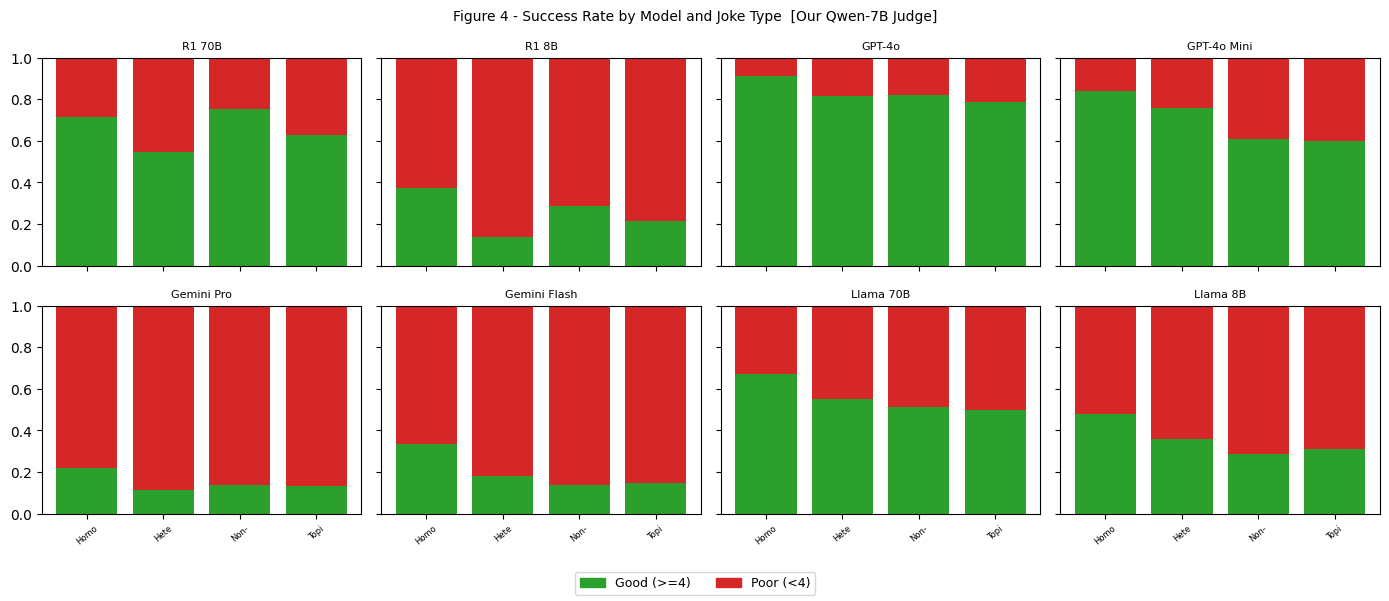

Saved to outputs/fig4_our_judge.png


In [16]:
# Figure 4 — Success rate grid
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

JOKE_TYPE_ORDER  = ["homographic", "heterographic", "non_topical", "topical"]
JOKE_TYPE_LABELS = {"homographic": "Homographic", "heterographic": "Heterographic",
                    "non_topical": "Non-Topical",  "topical": "Topical"}
MODEL_ORDER = ["r1-distill-llama-70b", "r1-distill-llama-8b",
               "gpt-4o", "gpt-4o-mini",
               "gemini-1.5-pro", "gemini-1.5-flash",
               "llama-3.1-70b", "llama-3.1-8b"]
MODEL_LABELS = {
    "r1-distill-llama-70b": "R1 70B",  "r1-distill-llama-8b": "R1 8B",
    "gpt-4o": "GPT-4o",                "gpt-4o-mini": "GPT-4o Mini",
    "gemini-1.5-pro": "Gemini Pro",     "gemini-1.5-flash": "Gemini Flash",
    "llama-3.1-70b": "Llama 70B",      "llama-3.1-8b": "Llama 8B",
}

if "df" not in dir() or len(df) == 0:
    print("Run the summary cell above first.")
else:
    piv = df.pivot_table(index=["joke_id", "joke_type", "model"],
                         columns="criterion", values="score", aggfunc="first").reset_index()
    piv.columns.name = None
    piv["is_good"] = (piv["accuracy"] >= 4) & (piv["completeness"] >= 4)
    sr = (piv.groupby(["model", "joke_type"])["is_good"]
             .mean().reset_index().rename(columns={"is_good": "success_rate"}))

    models = [m for m in MODEL_ORDER if m in sr["model"].unique()]
    jtypes = [t for t in JOKE_TYPE_ORDER if t in sr["joke_type"].unique()]

    fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharey=True, sharex=True)
    for ai, m in enumerate(models):
        ax = axes[ai // 4][ai % 4]
        goods = [float(sr[(sr["model"]==m)&(sr["joke_type"]==jt)]["success_rate"].iloc[0])
                 if len(sr[(sr["model"]==m)&(sr["joke_type"]==jt)]) else 0 for jt in jtypes]
        poors = [1-g for g in goods]
        x = np.arange(len(jtypes))
        ax.bar(x, goods, color="#2ca02c")
        ax.bar(x, poors, bottom=goods, color="#d62728")
        ax.set_title(MODEL_LABELS.get(m, m), fontsize=8)
        ax.set_xticks(x)
        ax.set_xticklabels([JOKE_TYPE_LABELS[t][:4] for t in jtypes], fontsize=6, rotation=40)
        ax.set_ylim(0, 1)

    fig.legend(handles=[mpatches.Patch(color="#2ca02c", label="Good (>=4)"),
                        mpatches.Patch(color="#d62728", label="Poor (<4)")],
               loc="lower center", ncol=2, fontsize=9)
    fig.suptitle("Figure 4 - Success Rate by Model and Joke Type  [Our Qwen-7B Judge]", fontsize=10)
    fig.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig("outputs/fig4_our_judge.png", dpi=150)
    plt.show()
    print("Saved to outputs/fig4_our_judge.png")

---
## Section 6 — Compare Our Judge vs Paper's Qwen-72B Baseline

The paper used Qwen-72B; we use Qwen-7B. This section shows how closely the two agree,  
proving our smaller judge is a valid substitute. Expect **moderate** agreement —  
the HANDOFF.md explicitly warns against expecting high agreement across model sizes.

In [17]:
# Pearson correlation + MAE
import pandas as pd, numpy as np

PAPER_RATINGS = Path("outputs/ratings_judge_paper.jsonl")
OUR_RATINGS   = Path("outputs/ratings_judge.jsonl")

if not OUR_RATINGS.exists() or OUR_RATINGS.stat().st_size == 0:
    print("Run Section 4 first.")
elif not PAPER_RATINGS.exists():
    print("outputs/ratings_judge_paper.jsonl not found.")
else:
    ours  = pd.DataFrame(load_jsonl(OUR_RATINGS)).rename(columns={"score": "score_ours"})
    paper = pd.DataFrame(load_jsonl(PAPER_RATINGS)).rename(columns={"score": "score_paper"})
    merged = ours.merge(paper[["joke_id", "model", "criterion", "score_paper"]],
                        on=["joke_id", "model", "criterion"], how="inner")
    merged["joke_type"] = merged["joke_id"].str.rsplit("_", n=1).str[0]

    print(f"Matched rows: {len(merged):,}\n")
    print(f"  {'Criterion':<14} {'Pearson r':>10} {'MAE':>8} {'Exact':>8} {'Within+/-1':>12}")
    print(f"  {'─'*56}")
    for crit in ["accuracy", "completeness"]:
        sub     = merged[merged["criterion"] == crit]
        r       = sub["score_ours"].corr(sub["score_paper"])
        mae     = (sub["score_ours"] - sub["score_paper"]).abs().mean()
        exact   = (sub["score_ours"] == sub["score_paper"]).mean()
        within1 = ((sub["score_ours"] - sub["score_paper"]).abs() <= 1).mean()
        print(f"  {crit.capitalize():<14} {r:>10.3f} {mae:>8.3f} {exact:>8.1%} {within1:>12.1%}")

    print()
    print("  Paper's Qwen-72B vs human: r=0.641/0.602  (our 7B will be lower — expected)")

Matched rows: 9,600

  Criterion       Pearson r      MAE    Exact   Within+/-1
  ────────────────────────────────────────────────────────
  Accuracy            0.623    0.456    56.7%        98.0%
  Completeness        0.716    0.491    52.0%        99.0%

  Paper's Qwen-72B vs human: r=0.641/0.602  (our 7B will be lower — expected)


  Criterion        Binary agree  Cohen kappa
  ────────────────────────────────────────────
  Accuracy                85.5%        0.547
  Completeness            75.6%        0.522

  kappa interpretation: >0.2 fair, >0.4 moderate, >0.6 substantial
  Paper reports kappa=0.565/0.519 for Qwen-72B vs human.


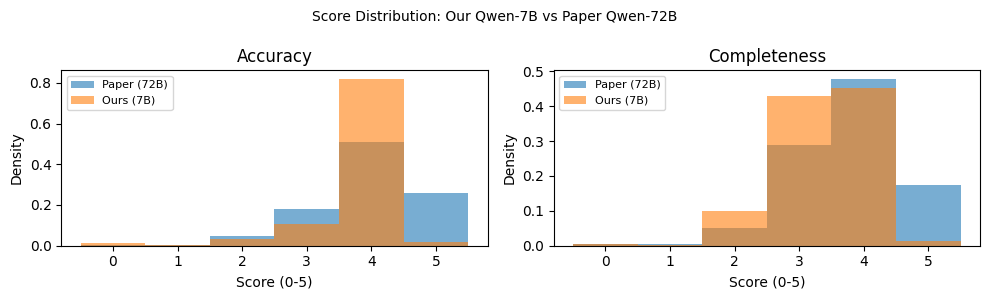

Saved to outputs/judge_comparison.png


In [18]:
# Cohen's kappa + score distribution plot
from sklearn.metrics import cohen_kappa_score

if "merged" not in dir() or len(merged) == 0:
    print("Run the cell above first.")
else:
    print(f"  {'Criterion':<14} {'Binary agree':>14} {'Cohen kappa':>12}")
    print(f"  {'─'*44}")
    for crit in ["accuracy", "completeness"]:
        sub = merged[merged["criterion"] == crit].copy()
        sub["pass_ours"]  = (sub["score_ours"]  >= 4).astype(int)
        sub["pass_paper"] = (sub["score_paper"] >= 4).astype(int)
        agree = (sub["pass_ours"] == sub["pass_paper"]).mean()
        kappa = cohen_kappa_score(sub["pass_paper"], sub["pass_ours"])
        print(f"  {crit.capitalize():<14} {agree:>14.1%} {kappa:>12.3f}")

    print()
    print("  kappa interpretation: >0.2 fair, >0.4 moderate, >0.6 substantial")
    print("  Paper reports kappa=0.565/0.519 for Qwen-72B vs human.")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    for ax, crit in zip(axes, ["accuracy", "completeness"]):
        sub  = merged[merged["criterion"] == crit]
        bins = np.arange(-0.5, 6, 1)
        ax.hist(sub["score_paper"], bins=bins, alpha=0.6, label="Paper (72B)", density=True)
        ax.hist(sub["score_ours"],  bins=bins, alpha=0.6, label="Ours (7B)",   density=True)
        ax.set_title(crit.capitalize())
        ax.set_xlabel("Score (0-5)")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
        ax.set_xticks(range(6))
    fig.suptitle("Score Distribution: Our Qwen-7B vs Paper Qwen-72B", fontsize=10)
    fig.tight_layout()
    plt.savefig("outputs/judge_comparison.png", dpi=150)
    plt.show()
    print("Saved to outputs/judge_comparison.png")